# Adversarial Search: Playing "Mean" Connect 4


## Instructions

Total Points: Undegraduates 10, graduate students 11

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed.

## Introduction

You will implement different versions of agents that play "Mean" Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

> **The mean part:** This game has an additional rule. Every time it is a player's turn, the player can decide to instead of playing a new disk, take a bottom row disk of the opponent and place it in any column. All disks above the removed disk will fall down one position. Note that a player can only move an _opponent's disc_ that is in the _bottom row_ of the board.

Note that normal [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [1 point]

Define the components of the search problem associated with this game:

* Initial state
* Actions
* Transition model
* Test for the terminal state
* Utility for terminal states

In [1]:
ROWS, COLS = 6, 7
EMPTY, MAXP, MINP = 0, 1, -1

from collections import namedtuple
Action = namedtuple("Action", ["type", "col", "dst"]) 
# type: "drop" hoặc "steal"
# col: với drop = cột thả; với steal = cột bị nhấc (đĩa đáy của đối thủ)
# dst: chỉ dùng cho "steal" = cột đặt lại đĩa vừa nhấc (None với drop)


How big is the state space? Give an estimate and explain it.

In [2]:
ROWS, COLS = 6, 7
state_space_upper = 3 ** (ROWS * COLS)
state_space_upper


109418989131512359209

How big is the game tree that minimax search will go through? Give an estimate and explain it.

In [3]:
b_est, d_max = 14, 42
float(b_est) ** d_max  # upper bound siêu thô


1.3720738853184972e+48

## Task 2: Game Environment and Random Agent [3 point]

You can use a numpy character array as the board. Note that the following function can create boards of different sizes.

In [4]:
import numpy as np

def in_bounds(r, c, board):
    return 0 <= r < board.shape[0] and 0 <= c < board.shape[1]

def drop(board, col, player):
    b = board.copy()
    for r in range(b.shape[0]-1, -1, -1):
        if b[r, col] == 0:
            b[r, col] = player
            return b
    return None  # cột đầy

def can_steal(board, col, player):
    # Chỉ được nhấc đĩa đáy của ĐỐI THỦ
    opponent = -player
    return board[-1, col] == opponent

def steal(board, src_col, dst_col, player):
    # Nhấc đĩa đáy của đối thủ ở src_col, mọi đĩa trên rơi xuống, rồi đặt đĩa đó lên dst_col (rơi theo trọng lực)
    if not can_steal(board, src_col, player):
        return None
    b = board.copy()
    taken = b[-1, src_col]
    b[1:, src_col] = b[:-1, src_col]   # tất cả rơi xuống 1 ô
    b[0, src_col] = 0
    # đặt lại đĩa đã lấy vào dst_col
    for r in range(b.shape[0]-1, -1, -1):
        if b[r, dst_col] == 0:
            b[r, dst_col] = taken
            return b
    return None  # dst_col đầy

def actions(board, player):
    acts = []
    # drop
    for c in range(board.shape[1]):
        if board[0, c] == 0:
            acts.append(Action("drop", c, None))
    # steal
    for src in range(board.shape[1]):
        if can_steal(board, src, player):
            for dst in range(board.shape[1]):
                # cho phép đặt lại vào chính cột src luôn
                if board[0, dst] == 0:
                    acts.append(Action("steal", src, dst))
    return acts

def result(board, action, player):
    if action.type == "drop":
        return drop(board, action.col, player)
    else:
        return steal(board, action.col, action.dst, player)

def check_winner(board):
    R, C = board.shape
    for r in range(R):
        for c in range(C):
            p = board[r, c]
            if p == 0: 
                continue
            # 4 hướng: ngang, dọc, chéo xuống phải, chéo lên phải
            dirs = [(0,1),(1,0),(1,1),(-1,1)]
            for dr, dc in dirs:
                ok = True
                for k in range(1,4):
                    rr, cc = r+dr*k, c+dc*k
                    if not in_bounds(rr,cc,board) or board[rr,cc]!=p:
                        ok=False; break
                if ok: 
                    return p
    return 0

def terminal(board):
    w = check_winner(board)
    if w != 0: 
        return True
    return not np.any(board[0]==0)  # đầy bàn

def utility(board, player):
    w = check_winner(board)
    if w == player: 
        return 1
    if w == -player: 
        return -1
    return 0


Instead of colors (red and yellow), you can use 1 and -1 to represent the players Max and Min. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position and player is the player (1, -1) whose next move it is and who the agent should play.

Visualization code by Randolph Rankin:

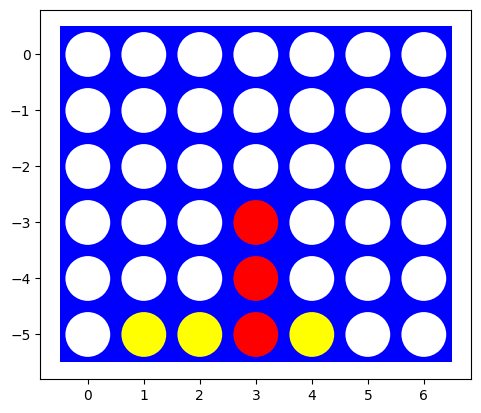

In [5]:
import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()
    
board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]

visualize(board)

Implement helper functions for:

* The transition model $result(s, a)$.
* The utility function $utility(s)$.
* Check for terminal states $terminal(s)$.
* A check for available actions in each state $actions(s)$.

Make sure that all these functions work with boards of different sizes (number of columns and rows).

In [6]:
import numpy as np

def in_bounds(r, c, board):
    return 0 <= r < board.shape[0] and 0 <= c < board.shape[1]

def drop(board, col, player):
    b = board.copy()
    for r in range(b.shape[0]-1, -1, -1):
        if b[r, col] == 0:
            b[r, col] = player
            return b
    return None  # cột đầy

def can_steal(board, col, player):
    # Chỉ được nhấc đĩa đáy của ĐỐI THỦ
    opponent = -player
    return board[-1, col] == opponent

def steal(board, src_col, dst_col, player):
    # Nhấc đĩa đáy của đối thủ ở src_col, mọi đĩa trên rơi xuống, rồi đặt đĩa đó lên dst_col (rơi theo trọng lực)
    if not can_steal(board, src_col, player):
        return None
    b = board.copy()
    taken = b[-1, src_col]
    b[1:, src_col] = b[:-1, src_col]   # tất cả rơi xuống 1 ô
    b[0, src_col] = 0
    # đặt lại đĩa đã lấy vào dst_col
    for r in range(b.shape[0]-1, -1, -1):
        if b[r, dst_col] == 0:
            b[r, dst_col] = taken
            return b
    return None  # dst_col đầy

def actions(board, player):
    acts = []
    # drop
    for c in range(board.shape[1]):
        if board[0, c] == 0:
            acts.append(Action("drop", c, None))
    # steal
    for src in range(board.shape[1]):
        if can_steal(board, src, player):
            for dst in range(board.shape[1]):
                # cho phép đặt lại vào chính cột src luôn
                if board[0, dst] == 0:
                    acts.append(Action("steal", src, dst))
    return acts

def result(board, action, player):
    if action.type == "drop":
        return drop(board, action.col, player)
    else:
        return steal(board, action.col, action.dst, player)

def check_winner(board):
    R, C = board.shape
    for r in range(R):
        for c in range(C):
            p = board[r, c]
            if p == 0: 
                continue
            # 4 hướng: ngang, dọc, chéo xuống phải, chéo lên phải
            dirs = [(0,1),(1,0),(1,1),(-1,1)]
            for dr, dc in dirs:
                ok = True
                for k in range(1,4):
                    rr, cc = r+dr*k, c+dc*k
                    if not in_bounds(rr,cc,board) or board[rr,cc]!=p:
                        ok=False; break
                if ok: 
                    return p
    return 0

def terminal(board):
    w = check_winner(board)
    if w != 0: 
        return True
    return not np.any(board[0]==0)  # đầy bàn

def utility(board, player):
    w = check_winner(board)
    if w == player: 
        return 1
    if w == -player: 
        return -1
    return 0


Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = None): ...`

The argument `player` is used for agents that do not store what side they are playing. The value passed on bt yhe environment should be 1 ot -1 for playerred and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [7]:
import random

def random_player(board, player=None):
    A = actions(board, player)
    return random.choice(A) if A else None


Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [8]:
def play_game(p1, p2, rows=6, cols=7, first=1):
    board = np.zeros((rows, cols), dtype=int)
    player = first
    while True:
        act = (p1 if player==1 else p2)(board, player)
        if act is None:
            return 0  # bế tắc
        board = result(board, act, player)
        if terminal(board):
            u = utility(board, 1)
            return u  # +1 nếu 1 thắng, -1 nếu 1 thua, 0 hòa
        player *= -1

N=1000
wins1=wins2=draw=0
for _ in range(N):
    res = play_game(random_player, random_player, rows=4, cols=5)  # dùng bảng nhỏ cho nhanh
    if res==1: wins1+=1
    elif res==-1: wins2+=1
    else: draw+=1

wins1, wins2, draw


(793, 205, 2)

## Task 3: Minimax Search with Alpha-Beta Pruning [3 points]

### Implement the search starting.

Implement the search starting from a given board and specifying the player and put it into an agent function.
You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).

__Notes:__ 
* Make sure that all your agent functions have a signature consistent with the random agent above.
* The search space for a $6 \times 7$ board is large. You can experiment with smaller boards (the smallest is $4 \times 4$) and/or changing the winning rule to connect 3 instead of 4.

In [18]:
# == THAY CẢ Ô NÀY BẰNG ĐOẠN NÀY: test + agent có cutoff, không còn RecursionError ==
import numpy as np, math

def np_board(list2d):
    return np.array(list2d, dtype=int)

# ---- Alpha-Beta có cutoff (không dùng heuristic) ----
def ab_cut(board, player, depth, root, alpha=-math.inf, beta=math.inf):
    # Cần các hàm: actions(board, player), result(board, action, player),
    # terminal(board), utility(board, player_root)
    if terminal(board):
        return utility(board, root)  # -1,0,1

    if depth == 0:
        return 0  # hết sâu thì coi như hòa tạm

    if player == root:
        v = -math.inf
        for a in actions(board, player):
            nb = result(board, a, player)
            v = max(v, ab_cut(nb, -player, depth-1, root, alpha, beta))
            alpha = max(alpha, v)
            if beta <= alpha:
                break
        return v
    else:
        v = math.inf
        for a in actions(board, player):
            nb = result(board, a, player)
            v = min(v, ab_cut(nb, -player, depth-1, root, alpha, beta))
            beta = min(beta, v)
            if beta <= alpha:
                break
        return v

def safe_minimax_agent(board, player=None, max_depth=6):
    root = player
    best_val, best_act = -math.inf, None
    for a in actions(board, player):
        nb = result(board, a, player)
        val = ab_cut(nb, -player, max_depth-1, root)
        if val > best_val:
            best_val, best_act = val, a
    return best_act

Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.

In [19]:
# ---- Các thế cờ để test ----
tests = [
    # gần thắng ngang (player=1 nên ưu tiên chốt hàng 4)
    np_board([
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [1,1,1,0,-1,0,0],
    ]),
    # chéo, cần block đối thủ
    np_board([
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,1,0,0,0],
        [0,0,1,-1,0,0,0],
        [0,1,-1,1,0,0,0],
        [1,-1,1,-1,0,0,0],
    ]),
    # thêm case khác nếu cần…
]

# ---- Chạy test (ĐÃ THAY minimax_agent → safe_minimax_agent) ----
for i, b in enumerate(tests, 1):
    a = safe_minimax_agent(b, player=1, max_depth=6)  # đổi agent ở đây
    print(i, a)

1 Action(type='drop', col=3, dst=None)
2 Action(type='drop', col=0, dst=None)


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [ ]:
import time, numpy as np

for cols in [4,5,6,7]:
    b = np.zeros((4, cols), dtype=int)
    t0 = time.time()

    _ = safe_minimax_agent(b, player=1, max_depth=6)


    print(f"cols={cols} | time={time.time()-t0:.3f}s")



cols=4 | time=0.111s
cols=5 | time=0.271s
cols=6 | time=0.559s
cols=7 | time=1.027s


### Move ordering

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?

In [22]:
def ordered_actions(board, player):
    cols = list(range(board.shape[1]))
    mid = board.shape[1]//2
    cols.sort(key=lambda c: abs(c-mid))  # giữa trước
    ordered=[]
    # ưu tiên drop trước, rồi steal
    for c in cols:
        if board[0,c]==0:
            ordered.append(Action("drop", c, None))
    for src in cols:
        if can_steal(board, src, player):
            for dst in cols:
                if board[0,dst]==0:
                    ordered.append(Action("steal", src, dst))
    return ordered

# dùng ordered_actions trong minimax:
# thay actions(board, player) -> ordered_actions(board, player)


### The first few moves

Start with an empty board. This is the worst case scenario for minimax search with alpha-beta pruning since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do? 

In [23]:
import time, math

def ab_cut(board, player, depth, alpha=-math.inf, beta=math.inf):
    if depth==0 or terminal(board):
        return utility(board, root_player)
    if player==root_player:
        v=-math.inf
        for a in ordered_actions(board, player):
            nb = result(board, a, player)
            v = max(v, ab_cut(nb, -player, depth-1, alpha, beta))
            alpha=max(alpha,v)
            if beta<=alpha: break
        return v
    else:
        v= math.inf
        for a in ordered_actions(board, player):
            nb = result(board, a, player)
            v = min(v, ab_cut(nb, -player, depth-1, alpha, beta))
            beta=min(beta,v)
            if beta<=alpha: break
        return v

def id_ab_agent(board, player=None, max_depth=6, time_limit=1.0):
    global root_player
    root_player = player
    best_a = None; t0=time.time()
    for d in range(1, max_depth+1):
        if time.time()-t0 > time_limit: break
        best, cand = -math.inf, None
        for a in ordered_actions(board, player):
            nb = result(board, a, player)
            val = ab_cut(nb, -player, d-1)
            if val > best:
                best, cand = val, a
        if cand is not None:
            best_a = cand
    return best_a


### Playtime

Let the Minimax Search agent play a random agent on a small board. Analyze wins, losses and draws.

In [24]:
N=200
res={'win':0,'loss':0,'draw':0}
for _ in range(N):
    r = play_game(lambda b,p: id_ab_agent(b,p, max_depth=4, time_limit=0.5),
                  random_player, rows=4, cols=5)
    if r==1: res['win']+=1
    elif r==-1: res['loss']+=1
    else: res['draw']+=1
res


{'win': 200, 'loss': 0, 'draw': 0}

## Task 4: Heuristic Alpha-Beta Tree Search [3 points] 

### Heuristic evaluation function

Define and implement a heuristic evaluation function.

In [27]:
import numpy as np

def line_score(count_self, count_opp, count_empty):
    if count_self==4: return 10_000
    if count_self==3 and count_empty==1: return 100
    if count_self==2 and count_empty==2: return 10
    if count_opp==3 and count_empty==1: return -80
    if count_opp==4: return -10_000
    return 0

def heuristic(board, player):
    opp = -player
    score = 0
    # ưu tiên cột giữa
    center_col = board[:, board.shape[1]//2]
    score += 3 * int(np.sum(center_col==player))
    # quét mọi cửa sổ 4
    R,C = board.shape
    def window_vals(cells):
        cs = np.sum(cells==player)
        co = np.sum(cells==opp)
        ce = np.sum(cells==0)
        return line_score(cs,co,ce)

    # ngang
    for r in range(R):
        for c in range(C-3):
            score += window_vals(board[r, c:c+4])
    # dọc
    for c in range(C):
        for r in range(R-3):
            score += window_vals(board[r:r+4, c])
    # chéo xuống phải
    for r in range(R-3):
        for c in range(C-3):
            score += window_vals(np.array([board[r+i, c+i] for i in range(4)]))
    # chéo lên phải
    for r in range(3, R):
        for c in range(C-3):
            score += window_vals(np.array([board[r-i, c+i] for i in range(4)]))
    return score


### Cutting off search 

Modify your Minimax Search with Alpha-Beta Pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [28]:
import math

def ab_heur(board, player, depth, alpha=-math.inf, beta=math.inf, root=None):
    if terminal(board):  # thật sự kết thúc
        u = utility(board, root)
        return u * 10_000
    if depth==0:
        return heuristic(board, root)
    if player==root:
        v=-math.inf
        for a in ordered_actions(board, player):
            nb = result(board, a, player)
            v = max(v, ab_heur(nb, -player, depth-1, alpha, beta, root))
            alpha=max(alpha,v)
            if beta<=alpha: break
        return v
    else:
        v= math.inf
        for a in ordered_actions(board, player):
            nb = result(board, a, player)
            v = min(v, ab_heur(nb, -player, depth-1, alpha, beta, root))
            beta=min(beta,v)
            if beta<=alpha: break
        return v

def heur_agent(board, player=None, depth=5):
    root = player
    best, best_a = -math.inf, None
    for a in ordered_actions(board, player):
        nb = result(board, a, player)
        val = ab_heur(nb, -player, depth-1, root=root)
        if val > best:
            best, best_a = val, a
    return best_a


Experiment with the same manually created boards as above to check if the agent spots winning opportunities.

In [29]:

import numpy as np

def np_board(list2d):
    return np.array(list2d, dtype=int)

tests = [
 
    np_board([
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [1,1,1,0,-1,0,0],
    ]),
  
    np_board([
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,1,0,0,0],
        [0,0,1,-1,0,0,0],
        [0,1,-1,1,0,0,0],
        [1,-1,1,-1,0,0,0],
    ]),
   
    np_board([
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,1,0,0,0,0],
    ]),
   
    np_board([
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [-1, 0, 0, 0, 0, 0, 0], 
    ]),
   
    np_board([
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,1,-1,0,0],
        [0,0,1,-1, 1,0,0],
        [0,1,-1, 1,-1,0,0],
    ]),
]

def print_board(b):
    chars = {0:'.', 1:'X', -1:'O'}
    for r in range(b.shape[0]):
        print(' '.join(chars[v] for v in b[r]))
    print('-' * (2*b.shape[1]-1))

for i, b in enumerate(tests, 1):
    print(f"[Test {i}]")
    print_board(b)
    a = heur_agent(b, player=1, depth=5)   # chỉnh depth nếu muốn nhanh/chậm
    print("→ Nước khuyên dùng:", a)
    nb = result(b, a, 1) if a is not None else b
    print("→ Sau khi đi:")
    print_board(nb)


[Test 1]
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
X X X . O . .
-------------
→ Nước khuyên dùng: Action(type='drop', col=3, dst=None)
→ Sau khi đi:
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
X X X X O . .
-------------
[Test 2]
. . . . . . .
. . . . . . .
. . . X . . .
. . X O . . .
. X O X . . .
X O X O . . .
-------------
→ Nước khuyên dùng: Action(type='drop', col=3, dst=None)
→ Sau khi đi:
. . . . . . .
. . . X . . .
. . . X . . .
. . X O . . .
. X O X . . .
X O X O . . .
-------------
[Test 3]
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . X . . . .
-------------
→ Nước khuyên dùng: Action(type='drop', col=3, dst=None)
→ Sau khi đi:
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . X X . . .
-------------
[Test 4]
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
O . . . . . .
-------------
→ Nước khuyên dùng: Action(type='drop', col=3, dst=None)
→ Sau kh

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [30]:
import time, numpy as np

def bench_heur(cols_list=(4,5,6,7), rows=4, depths=(3,4,5), repeat=3):
    results = []
    for c in cols_list:
        b = np.zeros((rows, c), dtype=int)
        for d in depths:
            times = []
            for _ in range(repeat):
                t0 = time.time()
                _ = heur_agent(b, player=1, depth=d)
                times.append(time.time() - t0)
            avg_t = sum(times)/len(times)
            results.append((rows, c, d, avg_t))
            print(f"rows={rows}, cols={c}, depth={d} → {avg_t:.4f}s (avg of {repeat})")
    return results

# Chạy 2 set: bảng nhỏ cho nhanh, rồi bảng chuẩn 6x7
print("== Bảng nhỏ 4x(4..7) ==")
small = bench_heur(cols_list=(4,5,6,7), rows=4, depths=(3,4,5), repeat=3)

print("\n== Bảng chuẩn 6x7 ==")
standard = []
b = np.zeros((6,7), dtype=int)
for d in (3,4,5):
    times = []
    for _ in range(3):
        t0 = time.time()
        _ = heur_agent(b, player=1, depth=d)
        times.append(time.time() - t0)
    avg_t = sum(times)/len(times)
    standard.append((6,7,d,avg_t))
    print(f"rows=6, cols=7, depth={d} → {avg_t:.4f}s (avg of 3)")

# Nếu muốn có bảng đẹp (tuỳ, cần pandas):
try:
    import pandas as pd
    df_small = pd.DataFrame(small, columns=["rows","cols","depth","avg_sec"])
    df_std   = pd.DataFrame(standard, columns=["rows","cols","depth","avg_sec"])
    print("\n--- Small Boards ---")
    display(df_small.pivot(index="cols", columns="depth", values="avg_sec").round(4))
    print("\n--- Standard 6x7 ---")
    display(df_std)
except Exception:
    pass


== Bảng nhỏ 4x(4..7) ==
rows=4, cols=4, depth=3 → 0.0107s (avg of 3)
rows=4, cols=4, depth=4 → 0.0563s (avg of 3)
rows=4, cols=4, depth=5 → 0.1632s (avg of 3)
rows=4, cols=5, depth=3 → 0.0283s (avg of 3)
rows=4, cols=5, depth=4 → 0.1716s (avg of 3)
rows=4, cols=5, depth=5 → 0.5287s (avg of 3)
rows=4, cols=6, depth=3 → 0.0497s (avg of 3)
rows=4, cols=6, depth=4 → 0.4020s (avg of 3)
rows=4, cols=6, depth=5 → 1.0996s (avg of 3)
rows=4, cols=7, depth=3 → 0.0790s (avg of 3)
rows=4, cols=7, depth=4 → 0.7803s (avg of 3)
rows=4, cols=7, depth=5 → 2.0978s (avg of 3)

== Bảng chuẩn 6x7 ==
rows=6, cols=7, depth=3 → 0.1693s (avg of 3)
rows=6, cols=7, depth=4 → 1.6258s (avg of 3)
rows=6, cols=7, depth=5 → 5.9776s (avg of 3)

--- Small Boards ---


depth,3,4,5
cols,,,
4,0.0107,0.0563,0.1632
5,0.0283,0.1716,0.5287
6,0.0497,0.4020,1.0996
7,0.0790,0.7803,2.0978



--- Standard 6x7 ---


,rows,cols,depth,avg_sec
0,6,7,3,0.169340
1,6,7,4,1.625750
2,6,7,5,5.977553


### Playtime

Let two heuristic search agents (different cutoff depth, different heuristic evaluation function) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

In [ ]:
# Your code/ answer goes here.

## Tournament task [+ 1 to 5 bonus point will be assigned separately]

Find another student and let your best agent play against the other student's best player. You are allowed to use any improvements you like as long as you code it yourself. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [1 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+1 Bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search (see [tic-tac-toe-example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_pure_monte_carlo_search.ipynb)) and investigate how this search performs on the test boards that you have used above. 

In [31]:
import random

def rollout(board, player):
    cur = player
    while not terminal(board):
        A = actions(board, cur)
        if not A: break
        a = random.choice(A)
        board = result(board, a, cur)
        cur *= -1
    return utility(board, player)

def pmcs_agent(board, player=None, sims_per_action=200):
    best, best_a = -1e18, None
    A = actions(board, player)
    for a in A:
        wins = 0
        for _ in range(sims_per_action):
            nb = result(board, a, player).copy()
            wins += rollout(nb, -player)
        if wins > best:
            best, best_a = wins, a
    return best_a


### Best First Move

How would you determine what the best first move for a standard board ($6 \times 7$) is? You can use Pure Monte Carlo Search or any algorithms that you have implemented above.

In [32]:
b = np.zeros((6,7), dtype=int)
move = pmcs_agent(b, player=1, sims_per_action=1000)  # hoặc heur_agent depth lớn
move


Action(type='drop', col=6, dst=None)